<a href="https://colab.research.google.com/github/binhduong160199/DataEngineering8/blob/develop/Kopie_von_Taxifahrer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd              # Bibliothek für Datenanalyse
import numpy as np               # Mathematische Funktionen & Arrays
import matplotlib.pyplot as plt  # Plotten von Diagrammen
import seaborn as sns            # Erweiterte Visualisierungen


In [28]:
from google.colab import drive   # Google Drive einbinden
drive.mount('/content/drive')    # Ordner /content/drive mit Drive verbinden

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
pd.set_option("display.float_format", "{:.2f}".format)
# Darstellung von Fließkommazahlen auf 2 Nachkommastellen festlegen
df = pd.read_parquet("/content/drive/MyDrive/dataset-dataEng./fhvhv_tripdata_2025-07.parquet")
# Datensatz im Parquet-Format aus Google Drive laden

In [30]:
df.head()       # Zeigt die ersten 5 Zeilen des DataFrames zur schnellen Übersicht

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
0,HV0003,B03404,B03404,2025-07-01 00:05:56,2025-07-01 00:08:03,2025-07-01 00:08:44,2025-07-01 00:28:42,65,179,9.93,...,0.00,0.00,0.00,26.11,N,N,N,N,N,0.00
1,HV0005,B03406,None,2025-07-01 00:09:38,2025-07-01 00:16:28,2025-07-01 00:17:28,2025-07-01 00:22:50,35,35,0.79,...,0.00,0.00,0.00,4.39,N,N,N,N,N,0.00
2,HV0003,B03404,B03404,2025-07-01 00:47:47,2025-07-01 00:51:20,2025-07-01 00:51:20,2025-07-01 01:04:56,233,143,3.05,...,2.75,0.00,0.00,12.53,N,N,N,N,N,1.50
3,HV0005,B03406,None,2025-07-01 00:05:36,2025-07-01 00:08:46,2025-07-01 00:09:18,2025-07-01 00:28:44,68,145,3.99,...,2.75,0.00,0.00,19.06,N,N,N,N,Y,1.50
4,HV0005,B03406,None,2025-07-01 00:10:04,2025-07-01 00:35:56,2025-07-01 00:35:58,2025-07-01 01:09:06,132,90,17.70,...,2.75,2.50,0.00,45.22,N,N,N,N,N,1.50


Data Cleaning (Schritt für Schritt):

**Entscheidung:**


*   Wenig NaN → Zeilen löschen (df.dropna())

*   Mittel → Auffüllen (Mittelwert/Median/Mode/"Unknown") (df.fillna(...))


*   Sehr viele → Spalte entfernen (df.drop(columns=...))


In [31]:
df.isna().sum()   # Anzahl der fehlenden Werte (NaN) pro Spalte anzeigen


,0
hvfhs_license_num,0
dispatching_base_num,0
originating_base_num,5492276
request_datetime,0
on_scene_datetime,0
pickup_datetime,0
dropoff_datetime,0
PULocationID,0
DOLocationID,0
trip_miles,0


Zeilen löschen (dropna)

Spalte bleibt erhalten
– Datenmenge wird kleiner

Spalte löschen (drop(columns))

Keine NaN-Probleme mehr
– Information der ganzen Spalte geht verloren

In [32]:
# df.drop(columns="originating_base_num")    # Spalte "originating_base_num" entfernen???

In [33]:
df_test = df.dropna(subset=["originating_base_num"]) # Zeilen löschen, in denen "originating_base_num" fehlt (NaN)


🚖 Unterschied Dispatching vs. Originating (wenn ≠)

Preisgestaltung

App A macht den Preis, gefahren wird aber von Firma B → Preis kann abweichen.

Fahrer-Bezahlung

Unterschied, ob Fahrer über eigene Plattform oder Partnerfirma fährt → Lohn kann anders sein.

Service-Qualität

Kunde bestellt bei Uber, kommt aber Lyft-Auto → Marke/Qualität mischt sich.

Regeln der Stadt (Regulatorik)

Manche Städte erlauben bestimmte Basen nicht → Fahrt läuft über andere Basis.

Statistische Analyse

Zeigt, wie oft Cross-Dispatch passiert → wichtig für Marktanteil, Kooperationen, Wettbewerb.

👉 Kurz: Wenn dispatch ≠ origin, hat das Folgen für Preis, Fahrer, Service, Regeln und Marktanalyse.

In [34]:
df_test["dispatch_origin_equal"] = (
    df_test["dispatching_base_num"] == df_test["originating_base_num"]
)

# Neue Spalte: True, wenn "dispatching_base_num" = "originating_base_num", sonst False


/tmp/ipython-input-2372965294.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["dispatch_origin_equal"] = (


In [35]:
df_test.groupby("dispatch_origin_equal")["driver_pay"].mean()
# Durchschnittlicher "driver_pay" je Gruppe:
# True → wenn dispatch = origin, False → wenn unterschiedlich


,driver_pay
dispatch_origin_equal,
False,20.49
True,21.16


In [36]:
df_test.groupby("dispatch_origin_equal")["driver_pay"].agg(["count", "mean", "median"])
# Für jede Gruppe (True/False): Anzahl der Fahrten, Durchschnittslohn und Medianlohn anzeigen
# Wenn dispatch = origin (True), ist der Fahrerlohn etwas höher – im Schnitt ca. 0,7 $ mehr(!)
# Achtung : Wir haben vorher alle Zeilen mit leerem originating_base_num entfernt –
#,Analyse basiert nur auf den vollständigen Daten.


,count,mean,median
dispatch_origin_equal,,,
False,46,20.49,14.48
True,14160690,21.16,15.68


**Fazit: **
Die Spalte dispatching_base_num reicht für die Analyse aus. Zwar gibt es 47 Fälle, in denen dispatch ≠ origin, aber der Unterschied im Fahrerlohn ist gering.
 Der statistische Test zeigt zudem, dass der p-Wert nicht signifikant ist – also kein echter, bedeutsamer Effekt vorliegt.

In [37]:
#Der t-Test zeigt: p-Wert ist groß → kein signifikanter Unterschied.
#Einfach gesagt: Fahrer verdienen bei dispatch = origin nur minimal mehr,
#aber statistisch ist das nicht bedeutsam.

from scipy import stats

same = df_test.loc[df_test["dispatch_origin_equal"], "driver_pay"].dropna()
diff = df_test.loc[~df_test["dispatch_origin_equal"], "driver_pay"].dropna()

t_stat, p_value = stats.ttest_ind(same, diff, equal_var=False)
print("t-istatistik:", t_stat, "p-değeri:", p_value)


t-istatistik: 0.23531780666025517 p-değeri: 0.81502968252856


Data Cleaning – Schritte

Fehlende Werte (NaN)
→ prüfen, löschen oder sinnvoll auffüllen

Unlogische Werte
→ z. B. negative Fahrtdauer, unmögliche Preise

Datentypen
→ Zahl, Datum, String korrekt setzen

Duplikate
→ doppelte Zeilen finden und entfernen

Ausreißer
→ Extremwerte prüfen, ggf. behandeln

Spaltenstruktur
→ unnötige Spalten löschen, sinnvolle Reihenfolge

Konsistenz-Kontrolle
→ stimmen Werte zueinander (z. B. Start < Ende)?

Endkontrolle
→ Überblick: saubere, konsistente Datenbasis


In [38]:
# Alle Basis-Checks (Meilen, Zeit, Lohn, Trinkgeld) sind unauffällig .
#Einzig auffällig: Fahrten über 5 Meilen, aber Fahrerlohn = 0.

df[df["trip_miles"] < 0]
df[df["trip_time"] <= 0]
df[df["driver_pay"] < 0]
df[df["tips"] < 0]
df[(df["driver_pay"] == 0) & (df["trip_miles"] > 5)]


,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
99804,HV0003,B03404,B03404,2025-07-01 07:44:41,2025-07-01 07:47:56,2025-07-01 07:49:56,2025-07-01 08:27:28,80,100,6.25,...,2.75,0.00,0.00,0.00,N,N,N,N,N,0.00
110815,HV0005,B03406,None,2025-07-01 08:53:01,2025-07-01 08:58:18,2025-07-01 08:59:02,2025-07-01 09:34:36,97,68,5.67,...,0.75,0.00,0.00,0.00,Y,N,N,N,N,1.50
117899,HV0003,B03404,B03404,2025-07-01 08:23:11,2025-07-01 08:24:51,2025-07-01 08:24:51,2025-07-01 08:48:34,208,126,6.28,...,0.00,0.00,0.00,0.00,N,N,N,N,N,0.00
204679,HV0003,B03404,B03404,2025-07-01 11:48:51,2025-07-01 11:55:02,2025-07-01 11:55:37,2025-07-01 12:27:57,228,21,5.64,...,0.00,0.00,0.00,0.00,N,N,N,N,N,0.00
235475,HV0003,B03404,B03404,2025-07-01 12:37:44,2025-07-01 12:38:53,2025-07-01 12:40:54,2025-07-01 13:30:30,76,37,5.59,...,0.00,0.00,0.00,0.00,N,N,N,N,N,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19419594,HV0005,B03406,None,2025-07-31 17:20:01,2025-07-31 17:28:50,2025-07-31 17:28:52,2025-07-31 18:55:21,68,241,14.53,...,0.75,0.00,0.00,0.00,Y,N,N,N,N,1.50
19459671,HV0005,B03406,None,2025-07-31 18:35:47,2025-07-31 18:43:46,2025-07-31 18:44:05,2025-07-31 19:32:11,68,265,5.44,...,0.00,0.00,0.00,0.00,Y,N,N,N,N,1.50
19466852,HV0005,B03406,None,2025-07-31 18:29:58,2025-07-31 18:43:09,2025-07-31 18:43:18,2025-07-31 19:12:04,68,82,7.41,...,0.75,0.00,0.00,0.00,Y,N,N,N,N,1.50
19549973,HV0005,B03406,None,2025-07-31 20:45:46,2025-07-31 20:49:00,2025-07-31 20:49:59,2025-07-31 21:18:11,246,1,18.89,...,0.00,1.25,0.00,0.00,Y,N,N,N,N,1.50


In [39]:
df["is_free_trip"] = df["driver_pay"] == 0
# Neue Spalte: True = Fahrt ohne Fahrerlohn (Gratisfahrt), False = normale Fahrt

df_paid → nur bezahlte Fahrten, für Analyse des Fahrerlohns

df → Originaltabelle mit Flag (is_free_trip), enthält alle Fahrten

In [40]:
df_paid = df[df["is_free_trip"] == False] # Neuer DataFrame nur mit bezahlten Fahrten (is_free_trip = False)


Fazit: Typen stimmen, Dataset ist sauber getrennt (Zeit, Zahl, Kategorie).
Bereit für 4. Duplikate und 5. Ausreißer.

In [41]:
# 3. SCHRITT: Typumwandlungen

# --- Datums-Spalten (in datetime umwandeln) ---
date_cols = ["request_datetime", "on_scene_datetime", "pickup_datetime", "dropoff_datetime"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)
        # errors="coerce" → nicht konvertierbare Werte werden NaT
        # utc=True → Standardformat, später evtl. in lokale Zeitzone umwandelbar

# --- Numerische Spalten (in numeric umwandeln) ---
num_cols = [
    "PULocationID","DOLocationID","trip_miles","trip_time",
    "base_passenger_fare","tolls","bcf","sales_tax",
    "congestion_surcharge","airport_fee","tips","driver_pay",
    "cbd_congestion_fee"
]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        # errors="coerce" → nicht-numerische Werte werden NaN


Fazit: Datentypen stimmen, große Datenbasis, bereit für Duplikat- und Ausreißer-Checks.

In [42]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19653012 entries, 0 to 19653011
Data columns (total 26 columns):
 #   Column                Dtype              
---  ------                -----              
 0   hvfhs_license_num     object             
 1   dispatching_base_num  object             
 2   originating_base_num  object             
 3   request_datetime      datetime64[us, UTC]
 4   on_scene_datetime     datetime64[us, UTC]
 5   pickup_datetime       datetime64[us, UTC]
 6   dropoff_datetime      datetime64[us, UTC]
 7   PULocationID          int32              
 8   DOLocationID          int32              
 9   trip_miles            float64            
 10  trip_time             int64              
 11  base_passenger_fare   float64            
 12  tolls                 float64            
 13  bcf                   float64            
 14  sales_tax             float64            
 15  congestion_surcharge  float64            
 16  airport_fee           float64     

In [43]:
# 4. Duplikat-Kontrolle

# Wie viele doppelte (genau gleiche) Zeilen gibt es?
dup_count = df.duplicated().sum()
print("Anzahl Duplikate:", dup_count)

# Wenn vorhanden → entfernen
if dup_count > 0:
    df = df.drop_duplicates()
    print("Zeilen nach Entfernen:", len(df))
else:
    print("Keine Duplikate, Tabelle unverändert:", len(df))



Anzahl Duplikate: 0
Keine Duplikate, Tabelle unverändert: 19653012


Fazit:
Die allermeisten Werte sind realistisch. Nur sehr wenige Extremwerte (155 sehr lange Fahrten, 224 sehr hohe Zahlungen) → Ausreißer existieren, aber Anteil minimal.
Diese können markiert/entfernt werden, je nach Analyseziel.

In [44]:
# 5. Ausreißer-Kontrolle (Outlier)

# Zusammenfassung der numerischen Spalten (Statistiken)
num_cols = [
    "trip_miles","trip_time","base_passenger_fare","tolls","bcf",
    "sales_tax","congestion_surcharge","airport_fee","tips","driver_pay","cbd_congestion_fee"
]

print("=== describe() – statistische Übersicht ===")
print(df[num_cols].describe(percentiles=[.01, .05, .5, .95, .99]).T)

# Manuelle Kontrolle sehr extremer Werte (Beispiel-Schwellen)
print("\n=== Ausreißer-Kontrolle ===")
if "trip_miles" in df.columns:
    print("trip_miles > 200:", df[df["trip_miles"] > 200].shape[0])
if "driver_pay" in df.columns:
    print("driver_pay > 500:", df[df["driver_pay"] > 500].shape[0])


=== describe() – statistische Übersicht ===
                           count    mean    std    min     1%     5%    50%  \
trip_miles           19653012.00    5.11   6.02   0.00   0.47   0.76   3.06   
trip_time            19653012.00 1188.20 858.32   1.00 192.00 304.00 967.00   
base_passenger_fare  19653012.00   26.57  24.87 -35.91   6.04   7.66  18.98   
tolls                19653012.00    1.10   3.59   0.00   0.00   0.00   0.00   
bcf                  19653012.00    0.67   0.65   0.00   0.13   0.18   0.47   
sales_tax            19653012.00    2.21   2.04   0.00   0.00   0.54   1.60   
congestion_surcharge 19653012.00    0.95   1.30   0.00   0.00   0.00   0.00   
airport_fee          19653012.00    0.22   0.72   0.00   0.00   0.00   0.00   
tips                 19653012.00    1.17   3.56   0.00   0.00   0.00   0.00   
driver_pay           19653012.00   20.73  18.46 -35.38   4.00   4.72  15.42   
cbd_congestion_fee   19653012.00    0.51   0.71   0.00   0.00   0.00   0.00   

       

“Beides” = zwei Sachen gleichzeitig machen ..

Im Original-DataFrame (df) nur Flag setzen → Ausreißer bleiben drin, gehen also nicht verloren. Du kannst sie später anschauen.

Zusätzlich einen gefilterten DataFrame (df_clean) bauen → hier sind die Ausreißer entfernt, damit Analysen (z. B. Fahrerlohn) nicht verzerrt sind.

So hast du beides:

df = vollständig + Flags

df_clean = bereinigt für saubere Analysen

In [45]:
# Flags hinzufügen (Ausreißer markieren, nicht löschen)
df["is_outlier_miles"] = df["trip_miles"] > 200
df["is_outlier_pay"]   = df["driver_pay"] > 500

# Bereinigtes Dataset (für Lohn-/Einnahmen-Analysen)
df_clean = df[(df["is_outlier_miles"] == False) & (df["is_outlier_pay"] == False)].copy()

print("Original-Daten:", len(df))
print("Bereinigte Daten (für Lohn-Analyse):", len(df_clean))



Original-Daten: 19653012
Bereinigte Daten (für Lohn-Analyse): 19652763


Schritt 6 – Spalten bereinigen:

Unnötige oder stark fehlende Spalten entfernen (z. B. originating_base_num).

Optional: Spaltennamen anpassen/vereinfachen (z. B. eindeutiger oder übersetzt).

In [46]:
if "originating_base_num" in df.columns:
    df = df.drop(columns=["originating_base_num"])
    df_clean = df_clean.drop(columns=["originating_base_num"], errors="ignore")


Zeitreihen-Test:
Bei einer Fahrt gilt: pickup_datetime < dropoff_datetime.
Wenn nicht (dropoff vor pickup), liegt ein Logikfehler vor.
➡️ Lösung: Solche Zeilen in der Regel entfernen.

In [47]:
# Anormale Zeilen finden, bei denen pickup > dropoff ist
time_errors = df[
    (df["pickup_datetime"].notna()) &
    (df["dropoff_datetime"].notna()) &
    (df["pickup_datetime"] > df["dropoff_datetime"])
]

print("Anzahl der Zeilen mit Zeitfehler:", len(time_errors))



Anzahl der Zeilen mit Zeitfehler: 0


Lokations-ID Kontrolle:
Jede Fahrt braucht eine Start- (PULocationID) und Ziel-ID (DOLocationID).
Keine 0 oder NaN gefunden → Daten sind in diesem Punkt sehr sauber.

In [48]:
loc_errors = df[
    (df["PULocationID"].isna()) | (df["DOLocationID"].isna()) |
    (df["PULocationID"] == 0)   | (df["DOLocationID"] == 0)
]

print("Lokasyon ID hatalı satır sayısı:", len(loc_errors))


Lokasyon ID hatalı satır sayısı: 0


Schritt 8 – Endkontrolle:

df.info() → zeigt Spaltentypen, Anzahl Nicht-Null-Werte, Speicherverbrauch

df.describe() → gibt Übersicht der numerischen Spalten: Minimum, Maximum, Mittelwert, Perzentile

In [49]:

# 8. ENDKONTROLLE

print("=== INFO ===")
print(df.info())   # Überblick: Spaltentypen, Nicht-Null-Werte, Speicher

print("\n=== NUMERISCHE ÜBERSICHT ===")
print(df.describe(percentiles=[.01, .05, .5, .95, .99]).T)   # Statistiken: Min, Max, Mittelwert, Perzentile


=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19653012 entries, 0 to 19653011
Data columns (total 27 columns):
 #   Column                Dtype              
---  ------                -----              
 0   hvfhs_license_num     object             
 1   dispatching_base_num  object             
 2   request_datetime      datetime64[us, UTC]
 3   on_scene_datetime     datetime64[us, UTC]
 4   pickup_datetime       datetime64[us, UTC]
 5   dropoff_datetime      datetime64[us, UTC]
 6   PULocationID          int32              
 7   DOLocationID          int32              
 8   trip_miles            float64            
 9   trip_time             int64              
 10  base_passenger_fare   float64            
 11  tolls                 float64            
 12  bcf                   float64            
 13  sales_tax             float64            
 14  congestion_surcharge  float64            
 15  airport_fee           float64            
 16  tips                 

Schritt 8 – Endkontrolle

27 Spalten, Datentypen korrekt verteilt (Datetime, Kategorie, Integer, Float, Bool)

Speicherverbrauch ca. 2,7 GB, durch Kategorien reduziert

Numerische Werte plausibel, nur wenige Ausreißer vorhanden und bereits markiert

Keine fehlenden Werte oder Duplikate, Zeit- und Lokationsangaben konsistent

Gesamt: Data Cleaning erfolgreich abgeschlossen.
Nächster Schritt: Explorative Datenanalyse (EDA) und Feature Engineering, z. B. Histogramme, Scatterplots und neue Variablen wie pay_per_mile, pay_per_hour oder avg_speed.

------------------------------------------------


Erster EDA-Durchlauf (ein Zellen-Code):

Histogramme → Verteilungen

Scatterplots → Zusammenhänge

Korrelationsmatrix (Heatmap) → Beziehungen zwischen numerischen Spalten

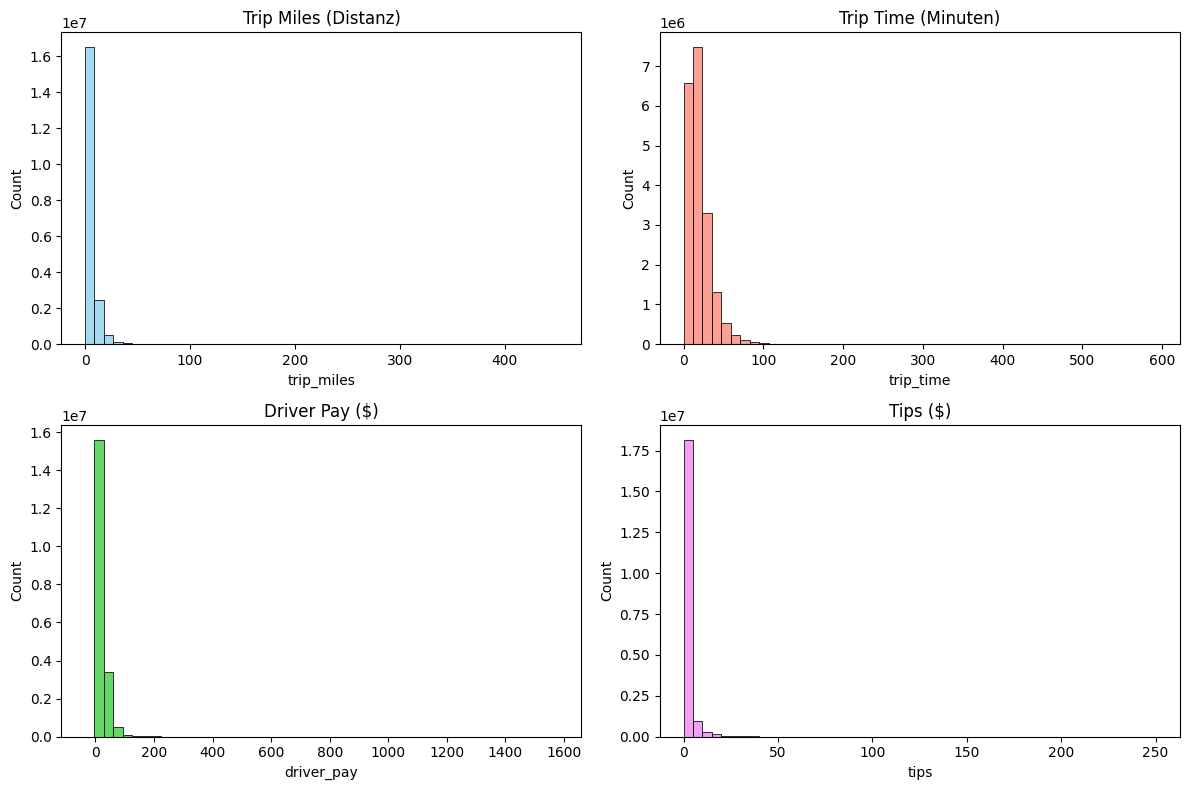

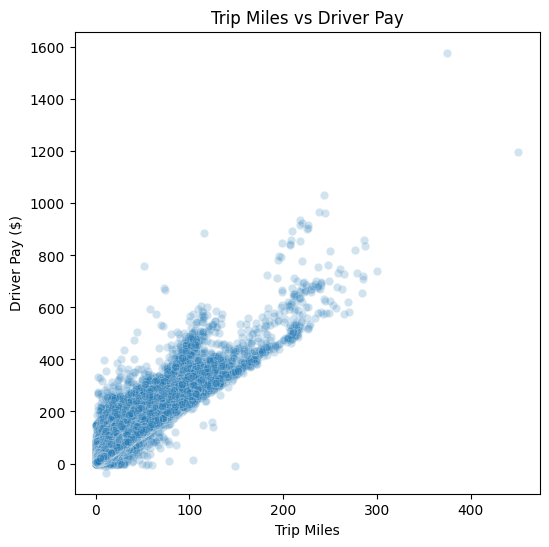

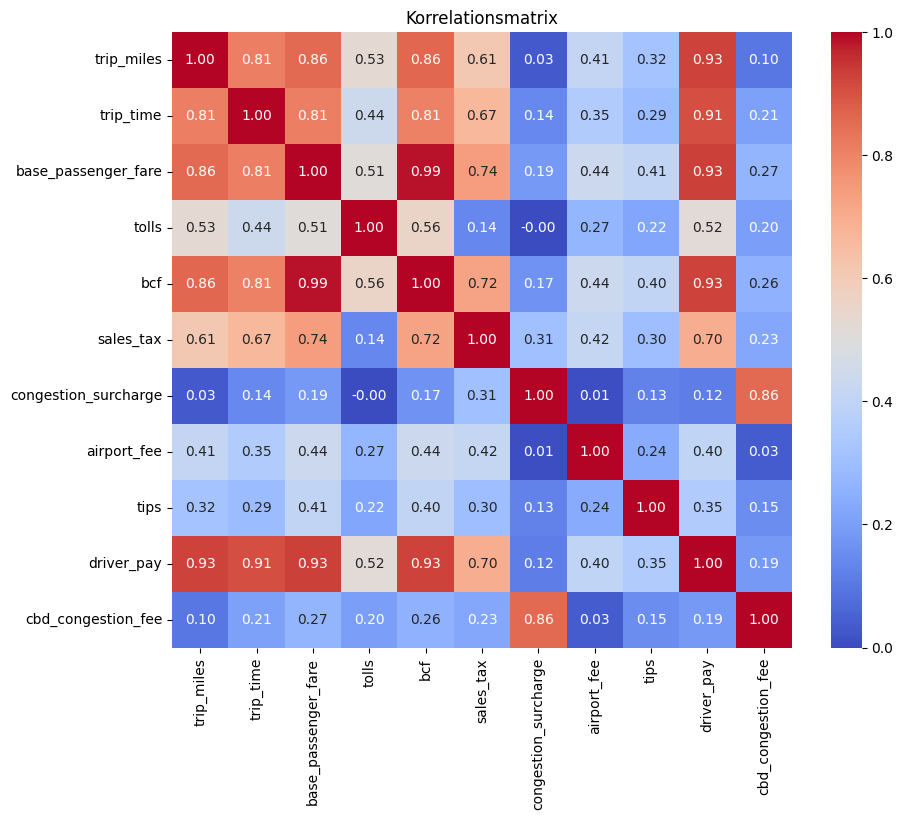

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Histogramme – Verteilungen
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df["trip_miles"], bins=50, ax=axes[0,0], color="skyblue")
axes[0,0].set_title("Trip Miles (Distanz)")

sns.histplot(df["trip_time"]/60, bins=50, ax=axes[0,1], color="salmon")
axes[0,1].set_title("Trip Time (Minuten)")

sns.histplot(df["driver_pay"], bins=50, ax=axes[1,0], color="limegreen")
axes[1,0].set_title("Driver Pay ($)")

sns.histplot(df["tips"], bins=50, ax=axes[1,1], color="violet")
axes[1,1].set_title("Tips ($)")

plt.tight_layout()
plt.show()

# 2) Scatterplot – Zusammenhang zwischen Distanz und Fahrerlohn
plt.figure(figsize=(6,6))
sns.scatterplot(x=df["trip_miles"], y=df["driver_pay"], alpha=0.2)
plt.xlabel("Trip Miles")
plt.ylabel("Driver Pay ($)")
plt.title("Trip Miles vs Driver Pay")
plt.show()

# 3) Korrelationsmatrix (Heatmap) – Beziehungen zwischen numerischen Spalten
num_cols = ["trip_miles","trip_time","base_passenger_fare","tolls","bcf",
            "sales_tax","congestion_surcharge","airport_fee","tips","driver_pay","cbd_congestion_fee"]

corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Korrelationsmatrix")
plt.show()



🔹 1. Histogramme

Fahrten meist 0–10 Meilen, wenige >100 (Ausreißer)

Dauer meist 0–60 Min., >100 Min. selten → typisch für NYC

Fahrerlohn meist 0–50 $, >200 $ selten

Trinkgeld oft 0, hohe Beträge selten
→ Alle Verteilungen rechtsschief

🔹 2. Scatterplot (Miles vs. Pay)

Klarer positiver Zusammenhang: mehr Meilen = mehr Lohn

Nicht nur Distanz zählt, auch Zeit, Gebühren, Tips

Einige extreme Punkte → markierte Ausreißer

🔹 3. Korrelationsmatrix

Sehr stark (>0.9): trip_miles, base_passenger_fare, driver_pay, bcf → fast gleiche Info

Hoch (0.8+): trip_miles ↔ trip_time

Niedrig (<0.3): tips, fees → unabhängig
 Fazit:

Daten plausibel: kurze Fahrten dominieren, Lohn folgt Distanz/Zeit, Tips unabhängig

Für Feature Engineering: neue Variablen wie pay_per_mile, pay_per_hour, avg_speed

Korrelationen nutzen:

0.3–0.7 = interessant für neue Features

0.8+ = zu ähnlich → evtl. eine Spalte weglassen

In [51]:
# Korrelationsmatrix in Long-Format darstellen
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ["Feature1", "Feature2", "Correlation"]

# Gleiche Spalten oder doppelte Paare entfernen
corr_pairs = corr_pairs[corr_pairs["Feature1"] < corr_pairs["Feature2"]]

# Die 10 höchsten Korrelationen sortieren und anzeigen (hier Top 40)
top_corr = corr_pairs.sort_values(by="Correlation", ascending=False).head(40)
print(top_corr)



                 Feature1              Feature2  Correlation
26    base_passenger_fare                   bcf         0.99
31    base_passenger_fare            driver_pay         0.93
99             driver_pay            trip_miles         0.93
53                    bcf            driver_pay         0.93
100            driver_pay             trip_time         0.91
44                    bcf            trip_miles         0.86
116    cbd_congestion_fee  congestion_surcharge         0.86
22    base_passenger_fare            trip_miles         0.86
23    base_passenger_fare             trip_time         0.81
1              trip_miles             trip_time         0.81
45                    bcf             trip_time         0.81
27    base_passenger_fare             sales_tax         0.74
49                    bcf             sales_tax         0.72
104            driver_pay             sales_tax         0.70
56              sales_tax             trip_time         0.67
55              sales_ta

🔹 Korrelationsbereiche (Daumenregel)

0.0–0.3 → schwach, meist vernachlässigbar

0.3–0.5 → mittel, kann neue Info geben

0.5–0.7 → stark, wichtig für Analyse

0.7–0.9 → sehr stark, Vorsicht im Modell

0.9 → fast identisch, Gefahr Multikollinearität

🔹 Interpretation Tabellen

high_corr (≥0.8)

Variablen erzählen fast dasselbe (z. B. trip_miles ↔ driver_pay).

Analyse: Zusammenhang beachten.

Modell: nur eine Variable wählen.

mid_corr (0.3–0.8)

Spannend für neue Features.

Beispiele:

tips ↔ driver_pay → Tip-Quote

tolls ↔ miles → Maut pro Meile

time ↔ miles → Durchschnittsgeschwindigkeit

📌 Fazit:

High_corr = redundant → Auswahl nötig.

Mid_corr = Quelle für neue Features.

In [52]:
import pandas as pd

# 1) Nur numerische Spalten für die Korrelationsmatrix
num_cols = [
    "trip_miles","trip_time","base_passenger_fare","tolls","bcf",
    "sales_tax","congestion_surcharge","airport_fee","tips","driver_pay","cbd_congestion_fee"
]
corr = df[num_cols].corr()

# 2) Long-Format (Feature1-Feature2-Korrelation)
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ["Feature1", "Feature2", "Correlation"]

# Gleiche Paare und Diagonale entfernen (A-B = B-A, A-A auslassen)
corr_pairs = corr_pairs[corr_pairs["Feature1"] < corr_pairs["Feature2"]]

# 3) Nach Schwellenwerten filtern
mid_corr  = corr_pairs[(corr_pairs["Correlation"] >= 0.3) & (corr_pairs["Correlation"] < 0.8)] \
                      .sort_values(by="Correlation", ascending=False)
high_corr = corr_pairs[corr_pairs["Correlation"] >= 0.8] \
                      .sort_values(by="Correlation", ascending=False)

# 4) Ergebnisse anzeigen
print("Top 10 höchste Korrelationen (meist Redundanz-Risiko):")
print(high_corr.head(10), "\n")

print("Top 15 mittelhohe Korrelationen (prüfenswert, neue Feature-Ideen):")
print(mid_corr.head(15), "\n")

print(f"Anzahl high_corr: {len(high_corr)}  |  Anzahl mid_corr: {len(mid_corr)}")

# 5) (Optional) Export als CSV
high_corr.to_csv("high_corr_pairs.csv", index=False)
mid_corr.to_csv("mid_corr_pairs.csv", index=False)
print("Gespeichert: high_corr_pairs.csv, mid_corr_pairs.csv")



Top 10 höchste Korrelationen (meist Redundanz-Risiko):
                Feature1              Feature2  Correlation
26   base_passenger_fare                   bcf         0.99
31   base_passenger_fare            driver_pay         0.93
99            driver_pay            trip_miles         0.93
53                   bcf            driver_pay         0.93
100           driver_pay             trip_time         0.91
44                   bcf            trip_miles         0.86
116   cbd_congestion_fee  congestion_surcharge         0.86
22   base_passenger_fare            trip_miles         0.86
23   base_passenger_fare             trip_time         0.81
1             trip_miles             trip_time         0.81 

Top 15 mittelhohe Korrelationen (prüfenswert, neue Feature-Ideen):
                Feature1             Feature2  Correlation
27   base_passenger_fare            sales_tax         0.74
49                   bcf            sales_tax         0.72
104           driver_pay            sal


Was ist next?

high_corr-Tabelle prüfen:
„Diese Spalten sind redundant, im Modell würde ich nicht beide gleichzeitig verwenden.“

mid_corr-Tabelle prüfen:
„Kann ich aus diesen Zusammenhängen neue abgeleitete Spalten bilden?“

Beispiele:

tips & driver_pay → Trinkgeld-Quote

trip_time & trip_miles → Durchschnittsgeschwindigkeit

Fazit: Jetzt musst du entscheiden –
Welche Variablen sind redundant?
Welche mittleren Korrelationen sind wertvoll für neue Features?